<a href="https://colab.research.google.com/github/Isaac-1-lang/Computer_Vision_Models/blob/main/DETR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using cache found in /root/.cache/torch/hub/facebookresearch_detr_main


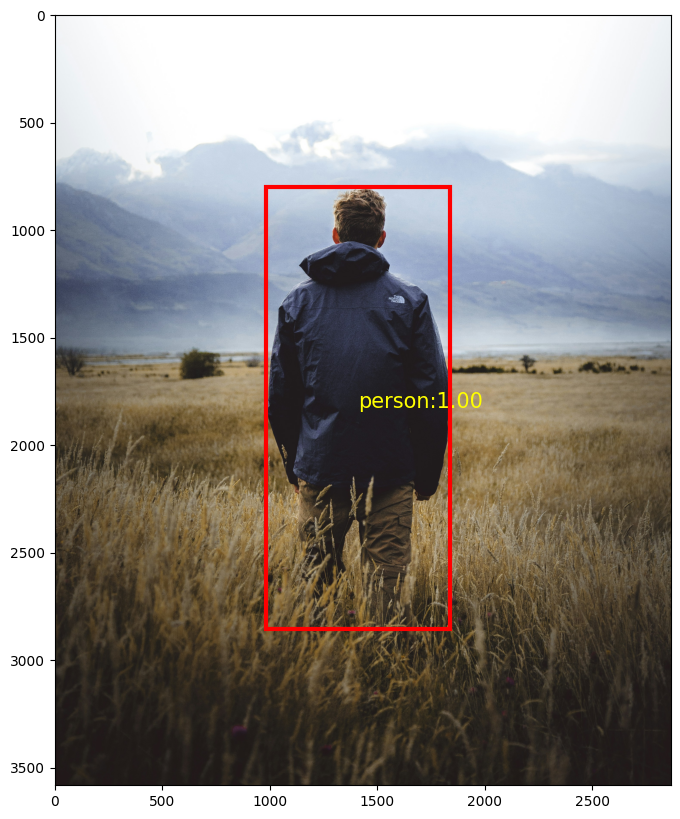

In [10]:
from turtle import color
from unittest import TestResult
import torch
import torchvision.transforms as T
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt



# Load pretrained DETR


model  = torch.hub.load('facebookresearch/detr','detr_resnet50',pretrained=True)
model.eval() # Set to evaluation mode




url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
image = Image.open(BytesIO(requests.get(url).content))



transform = T.Compose([
  T.Resize(800),
  T.ToTensor(),
  T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


img_tensor = transform(image).unsqueeze(0)   # Add batch dimension




outputs = model(img_tensor)



# COCO classes
CLASSES = [
    'N/A','person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat','dog',
    'horse','sheep','cow','elephant','bear','zebra','giraffe','backpack','umbrella',
    'handbag','tie','suitcase','frisbee','skis','snowboard','sports ball','kite',
    'baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle',
    'wine glass','cup','fork','knife','spoon','bowl','cupboard','apple','sandwich','orange',
    'broccoli','carrot','hot dog','pizza','donut','cake','chair','couch','potted plant',
    'bed','dining table','toilet','TV','laptop','mouse','remote','keyboard','cell phone',
    'microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors',
    'teddy bear','hair drier','toothbrush'
]



probabilities = outputs['pred_logits'].softmax(-1)[0,:,:-1]
boxes = outputs['pred_boxes'][0]





top_probs,labels = probabilities.max(-1)

threshold = 0.7


keep = top_probs > threshold



boxes = boxes[keep]
labels = labels[keep]
probs = top_probs[keep]



img_w,img_h=image.size


boxes = boxes*torch.tensor([img_w,img_h,img_w,img_h], dtype=torch.float32)




fig,ax=plt.subplots(1,1,figsize=(16,10))


ax.imshow(image)



for box,label,prob in zip(boxes,labels,probs):
  x_c,y_c,w,h=box

  rect = plt.Rectangle(
    (float(x_c-0.5*w),float(y_c-0.5*h)),float(w),float(h),fill=False,color='red',linewidth=3
  )
  ax.add_patch(rect)
  ax.text(float(x_c),float(y_c),f'{CLASSES[label]}:{prob:.2f}',fontsize=15,color='yellow')

plt.show()